In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Chocolate_Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [3]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64


In [5]:
df.info()
df.isna().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 154.0+ KB


,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


Task 1: Data Quality Issues

The dataset was checked for data quality issues by examining data types, missing values, and numerical summaries. The Date column was converted to datetime format, and the Amount column was converted from object to numeric after removing dollar signs and commas. Missing values were checked using isna().sum(). The dataset currently has no missing values because all columns contain 3282 non-null values. Outliers will be examined later in the Amount column using a boxplot and IQR method.

In [6]:
df.isna().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [7]:
df2 = df.copy()
df2.loc[0:5, 'Amount'] = np.nan
df2.isna().sum()
df2.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


Task2 : Missing values were handled using median imputation on the Amount column. This strategy was chosen because the median is more robust to outliers than the mean and is safer when the data may contain extreme values. Missing values were replaced with the median of the Amount column, which preserved the dataset size without deleting records.

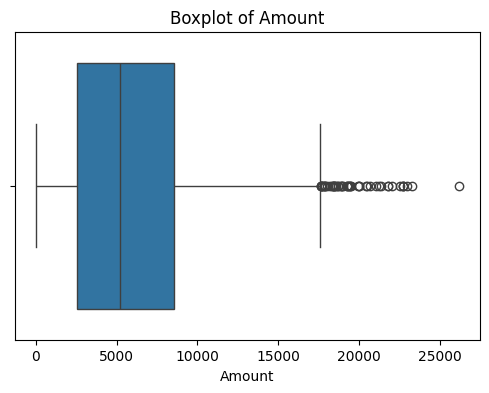

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Amount')
plt.show()

In [10]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)
print("Number of outliers:", outliers.shape[0])

Number of outliers: 50


In [11]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]

print("Original shape:", df.shape)
print("Without outliers shape:", df_no_outliers.shape)

Original shape: (3282, 6)
Without outliers shape: (3232, 6)


Task 3: Outliers in the Amount column were detected using the Interquartile Range (IQR) method. First, Q1 and Q3 were calculated, then the IQR was found as Q3 - Q1. Values outside the range Q1 - 1.5×IQR and Q3 + 1.5×IQR were considered outliers. These records were removed to create a cleaner dataset for analysis.

In [12]:
scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount,Boxes Shipped
0,0.203066,0.230373
1,0.301522,0.119691
2,0.171763,0.115830
3,0.486127,0.438867
4,0.522780,0.235521


Task 4: Min-Max normalization was applied to the Amount and Boxes Shipped columns using MinMaxScaler. This method rescales the values to a range between 0 and 1 while preserving the relative ordering of the data. It is useful when features have different scales.

In [13]:
scaler = StandardScaler()
df_standardized = df[['Amount', 'Boxes Shipped']].copy()

df_standardized[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Amount,Boxes Shipped
0,-0.161686,0.123648
1,0.424660,-0.569868
2,-0.348106,-0.594061
3,1.524058,1.430038
4,1.742345,0.155904


Z-score normalization was applied using StandardScaler to standardize the Amount and Boxes Shipped columns. After transformation, the features are centered around 0 with a standard deviation of 1. This makes the features comparable and is useful for many machine learning algorithms.

                 Amount  Boxes Shipped
Amount         1.000000      -0.013154
Boxes Shipped -0.013154       1.000000


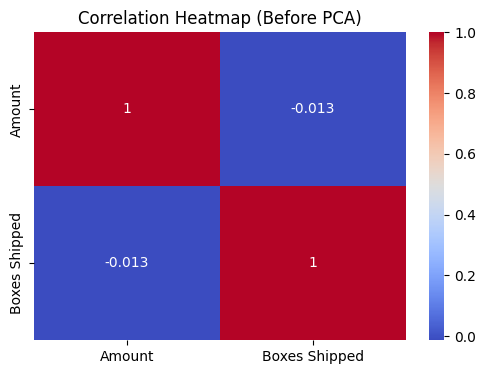

In [14]:
corr_matrix = df_standardized[['Amount', 'Boxes Shipped']].corr()
print(corr_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

Task 5: The correlation between the numerical features was checked before applying PCA. The correlation value between Amount and Boxes Shipped was -0.013, which is very close to 0. This means there is almost no linear relationship between the two features. Therefore, PCA was not necessary because dimensionality reduction is more useful when features are strongly correlated.